### M4-B Skeleton-Based LSTM — Behaviour from Body Movement
**Why this approach:**
The CNN+LSTM feeds raw pixels to MobileNetV3 → 576 features per frame.
~99% of those features encode background (parking lot, wall, lighting).
The model memorizes video-specific backgrounds instead of learning behaviour.

This notebook removes the CNN entirely:
1. YOLOv8-pose extracts 17 body keypoints per person per frame
2. Velocity features capture how fast each joint moves
3. A small LSTM receives ONLY joint positions + velocities (85 features/frame)
4. ~50K params vs 2.3M → cannot memorize, must generalize

**Pipeline:** Video → YOLOv8-pose → Skeleton clips → LSTM → Violence/Threat/Normal

In [1]:
import os, cv2, gc, random, time, sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — UPDATE THESE PATHS
# ══════════════════════════════════════════════════════════════════════════════
DATASET_ROOT = r'../Anomaly_Videos'       # ← Your UCF-Crime dataset path

TARGET_CLASSES = ['Violence', 'Threat', 'Normal']

CLASS_FOLDER_MAP = {
    'Violence': ['Abuse', 'Assault', 'Fighting'],
    'Threat':   ['Arson', 'Explosion', 'Burglary', 'Arrest'],
    'Normal':   ['Normal-Videos-Part-1'],
}

# Skeleton extraction settings
SKEL_CLIP_FRAMES = 16       # frames per clip
SKEL_CLIP_STRIDE = 16       # NO overlap — each clip has unique frames
SKEL_ROOT        = r'../M4B_skeleton_clips'
SKEL_TRAIN_RATIO = 0.80

SKEL_MAX_CLIPS = {
    'Violence': 4000,
    'Threat':   4000,
    'Normal':   6000,
}

N_KEYPOINTS = 17  # COCO format

# Training settings
SKEL_EPOCHS   = 50
SKEL_BATCH    = 32
SKEL_LR       = 1e-3
SKEL_PATIENCE = 12
SKEL_SAVE     = r'runs/M4B_classifier/SkeletonLSTM/best.pt'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ══════════════════════════════════════════════════════════════════════════════
# Verify setup
# ══════════════════════════════════════════════════════════════════════════════
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

if os.path.exists(DATASET_ROOT):
    print(f'✅ Dataset found: {DATASET_ROOT}')
else:
    print(f'❌ Dataset NOT found: {DATASET_ROOT}')
    print('   Update DATASET_ROOT above')

print(f'\nClasses: {TARGET_CLASSES}')
print(f'Skeleton save: {SKEL_ROOT}')
print(f'Model save: {SKEL_SAVE}')


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB
✅ Dataset found: ../Anomaly_Videos

Classes: ['Violence', 'Threat', 'Normal']
Skeleton save: ../M4B_skeleton_clips
Model save: runs/M4B_classifier/SkeletonLSTM/best.pt


In [2]:
# ── Find videos for each class ─────────────────────────────────────────────────
def find_class_videos(dataset_root, class_name):
    root = Path(dataset_root)
    videos = []
    folders = CLASS_FOLDER_MAP.get(class_name, [class_name])
    for folder_name in folders:
        for folder in root.rglob('*'):
            if folder.is_dir() and folder.name == folder_name:
                for ext in ['*.mp4', '*.avi', '*.MP4', '*.AVI']:
                    videos.extend(folder.glob(ext))
            elif folder.is_dir() and folder_name.lower() in folder.name.lower():
                for ext in ['*.mp4', '*.avi', '*.MP4', '*.AVI']:
                    videos.extend(folder.glob(ext))
    return sorted(set(videos))


# Scan dataset
print('Scanning dataset...')
print()
class_videos = {}
for cls in TARGET_CLASSES:
    vids = find_class_videos(DATASET_ROOT, cls)
    class_videos[cls] = vids
    src = str(CLASS_FOLDER_MAP.get(cls, [cls]))[:40]
    print(f'  {cls:<12} ← {src:<42} {len(vids):>4} videos')

total_v = sum(len(v) for v in class_videos.values())
print(f'  {"TOTAL":<12}   {"":42} {total_v:>4} videos')


Scanning dataset...

  Violence     ← ['Abuse', 'Assault', 'Fighting']            150 videos
  Threat       ← ['Arson', 'Explosion', 'Burglary', 'Arre    250 videos
  Normal       ← ['Normal-Videos-Part-1']                    150 videos
  TOTAL                                                      550 videos


In [3]:
from ultralytics import YOLO

# Load pose model
print('Loading YOLOv8n-pose model...')
pose_model = YOLO('yolov8n-pose.pt')
print('✅ Pose model loaded')
print()

# ── Skeleton extraction functions ─────────────────────────────────────────────
def extract_skeleton_from_frame(frame, pose_model):
    """Extract the dominant person's 17 keypoints from a frame."""
    results = pose_model(frame, verbose=False, conf=0.3)[0]
    if results.keypoints is None or len(results.keypoints) == 0:
        return None

    h, w = frame.shape[:2]
    keypoints_data = results.keypoints.data
    if keypoints_data.shape[0] == 0:
        return None

    # Pick person with most visible keypoints
    visibility = keypoints_data[:, :, 2]
    best_person = visibility.sum(dim=1).argmax().item()
    kps = keypoints_data[best_person].cpu().numpy()  # (17, 3)

    # Normalize to [0,1]
    kps[:, 0] /= w
    kps[:, 1] /= h
    return kps


def extract_skeleton_clips_from_video(video_path, pose_model,
                                       clip_frames=SKEL_CLIP_FRAMES,
                                       stride=SKEL_CLIP_STRIDE):
    """Extract non-overlapping skeleton clips from a video."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []

    all_skeletons = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        skel = extract_skeleton_from_frame(frame, pose_model)
        if skel is not None:
            all_skeletons.append(skel)
        else:
            all_skeletons.append(np.zeros((N_KEYPOINTS, 3), dtype=np.float32))
    cap.release()

    if len(all_skeletons) < clip_frames:
        return []

    clips = []
    for start in range(0, len(all_skeletons) - clip_frames + 1, stride):
        clip = np.stack(all_skeletons[start:start + clip_frames])
        # Skip clips where >50% frames have no detection
        valid_frames = (clip[:, :, 2].sum(axis=1) > 0).sum()
        if valid_frames >= clip_frames * 0.5:
            clips.append(clip.astype(np.float32))
    return clips


# ── Run extraction ────────────────────────────────────────────────────────────
print('='*65)
print('  EXTRACTING SKELETON CLIPS')
print('  YOLOv8-pose → 17 keypoints per person per frame')
print('  No pixels, no backgrounds — pure body movement data')
print(f'  Stride={SKEL_CLIP_STRIDE} → 0% frame overlap')
print('='*65)
print()

skel_stats = {}
for cls in TARGET_CLASSES:
    train_dir = Path(SKEL_ROOT) / 'train' / cls
    val_dir   = Path(SKEL_ROOT) / 'val' / cls

    # Skip if already extracted
    if train_dir.exists() and val_dir.exists():
        n_t = len(list(train_dir.glob('*.npy')))
        n_v = len(list(val_dir.glob('*.npy')))
        if n_t > 0 and n_v > 0:
            print(f'  ✅ {cls}: already extracted (train={n_t:,}  val={n_v:,}) — skipping')
            skel_stats[cls] = {'train': n_t, 'val': n_v}
            continue

    videos = class_videos[cls]
    if not videos:
        print(f'  ⚠️  {cls}: no videos found')
        skel_stats[cls] = {'train': 0, 'val': 0}
        continue

    # Split by video (80/20)
    random.seed(42)
    shuffled = list(videos)
    random.shuffle(shuffled)
    n_train = max(1, int(len(shuffled) * SKEL_TRAIN_RATIO))
    train_vids = shuffled[:n_train]
    val_vids = shuffled[n_train:]

    max_cap = SKEL_MAX_CLIPS.get(cls, 3000)
    max_train = int(max_cap * SKEL_TRAIN_RATIO)
    max_val = max_cap - max_train

    print(f'  Extracting {cls} ({len(videos)} videos: {len(train_vids)} train, {len(val_vids)} val)...')

    for split, vid_list, split_cap in [('train', train_vids, max_train),
                                         ('val', val_vids, max_val)]:
        out_dir = Path(SKEL_ROOT) / split / cls
        out_dir.mkdir(parents=True, exist_ok=True)
        split_total = 0

        for vpath in tqdm(vid_list, desc=f'    {cls}/{split}', file=sys.stdout, leave=False):
            clips = extract_skeleton_clips_from_video(vpath, pose_model)
            for ci, clip in enumerate(clips):
                if split_cap and split_total >= split_cap:
                    break
                fname = out_dir / f'{vpath.stem[:25]}_s{ci:04d}.npy'
                np.save(str(fname), clip)
                split_total += 1
            if split_cap and split_total >= split_cap:
                break

    t = len(list((Path(SKEL_ROOT)/'train'/cls).glob('*.npy')))
    v = len(list((Path(SKEL_ROOT)/'val'/cls).glob('*.npy')))
    skel_stats[cls] = {'train': t, 'val': v}
    print(f'    → train={t:,}  val={v:,}')

# Summary
print()
print('='*60)
print(f'  {"Class":<12} {"Train":>8} {"Val":>8} {"Total":>8}')
print('  ' + '-'*40)
total_t = total_v = 0
for cls in TARGET_CLASSES:
    t = skel_stats[cls]['train']
    v = skel_stats[cls]['val']
    total_t += t; total_v += v
    print(f'  {cls:<12} {t:>8,} {v:>8,} {t+v:>8,}')
print('  ' + '-'*40)
print(f'  {"TOTAL":<12} {total_t:>8,} {total_v:>8,} {total_t+total_v:>8,}')
print('='*60)

# Free GPU memory
del pose_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('\n✅ Pose model released from GPU memory')

Loading YOLOv8n-pose model...
✅ Pose model loaded

  EXTRACTING SKELETON CLIPS
  YOLOv8-pose → 17 keypoints per person per frame
  No pixels, no backgrounds — pure body movement data
  Stride=16 → 0% frame overlap

  Extracting Violence (150 videos: 120 train, 30 val)...
    → train=3,200  val=800                                            
  Extracting Threat (250 videos: 200 train, 50 val)...
    → train=3,200  val=800                                           
  Extracting Normal (150 videos: 120 train, 30 val)...
    → train=4,800  val=1,200                                         

  Class           Train      Val    Total
  ----------------------------------------
  Violence        3,200      800    4,000
  Threat          3,200      800    4,000
  Normal          4,800    1,200    6,000
  ----------------------------------------
  TOTAL          11,200    2,800   14,000

✅ Pose model released from GPU memory


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# DATASET: Skeleton clips with velocity features
# ══════════════════════════════════════════════════════════════════════════════
class SkeletonClipDataset(Dataset):
    """
    Loads skeleton clips (T, 17, 3) and computes velocity features.
    Output per frame: 17 joints × (x, y, conf, vx, vy) = 85 features.
    """
    def __init__(self, skel_root, split, target_classes, augment=False):
        self.samples = []
        self.augment = augment
        root = Path(skel_root) / split
        for ci, cls in enumerate(target_classes):
            cls_dir = root / cls
            if not cls_dir.exists():
                continue
            for npy_path in cls_dir.glob('*.npy'):
                self.samples.append((npy_path, ci))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path))  # (T, 17, 3)
        T, J, _ = clip.shape

        # ── Augmentation (training only) ──────────────────────────────────
        if self.augment:
            # Horizontal flip (mirror skeleton)
            if random.random() > 0.5:
                clip[:, :, 0] = 1.0 - clip[:, :, 0]
                swap_pairs = [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]
                for l, r in swap_pairs:
                    clip[:, [l, r]] = clip[:, [r, l]]

            # Small translation
            dx = random.uniform(-0.05, 0.05)
            dy = random.uniform(-0.05, 0.05)
            clip[:, :, 0] = np.clip(clip[:, :, 0] + dx, 0, 1)
            clip[:, :, 1] = np.clip(clip[:, :, 1] + dy, 0, 1)

            # Scale variation
            scale = random.uniform(0.9, 1.1)
            cx = clip[:, :, 0].mean()
            cy = clip[:, :, 1].mean()
            clip[:, :, 0] = np.clip((clip[:, :, 0] - cx) * scale + cx, 0, 1)
            clip[:, :, 1] = np.clip((clip[:, :, 1] - cy) * scale + cy, 0, 1)

            # Temporal jitter (drop 1 frame, duplicate another)
            if random.random() > 0.7 and T > 8:
                drop_idx = random.randint(1, T - 2)
                clip = np.delete(clip, drop_idx, axis=0)
                clip = np.concatenate([clip, clip[-1:]], axis=0)

        # ── Velocity features ────────────────────────────────────────────
        positions = clip[:, :, :2]   # (T, 17, 2)
        velocity = np.zeros_like(positions)
        velocity[1:] = positions[1:] - positions[:-1]

        # Combine: (T, 17, 5) = [x, y, conf, vx, vy]
        features = np.concatenate([clip, velocity], axis=2)
        features = features.reshape(T, -1)  # (T, 85)

        return torch.tensor(features, dtype=torch.float32), label


# ══════════════════════════════════════════════════════════════════════════════
# MODEL: Lightweight LSTM for skeleton-based action recognition
# ══════════════════════════════════════════════════════════════════════════════
class SkeletonLSTM(nn.Module):
    """
    Input:  (batch, 16, 85) — 16 frames × 85 features
    Output: (batch, num_classes)

    Architecture:
        LayerNorm → LSTM(128, 1 layer) → Dropout → Linear(64) → Linear(3)

    ~50K params vs 2.3M in CNN+LSTM (46x smaller)
    """
    def __init__(self, input_dim=85, hidden_size=128, num_layers=1,
                 num_classes=3, dropout=0.4):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.input_norm(x)
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1])


# ── Verify model ──────────────────────────────────────────────────────────────
model_test = SkeletonLSTM(num_classes=len(TARGET_CLASSES)).to(DEVICE)
dummy = torch.zeros(2, SKEL_CLIP_FRAMES, 85).to(DEVICE)
out = model_test(dummy)

total_params = sum(p.numel() for p in model_test.parameters())
print(f'Model output shape:  {out.shape}')
print(f'Total parameters:    {total_params:,}')
print(f'CNN+LSTM had:        2,308,131 params')
print(f'Reduction:           {2308131/total_params:.0f}x smaller')
print(f'Param/sample ratio:  ~{total_params/9600:.1f} (CNN+LSTM was 240)')

del model_test, dummy
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
print('\n✅ Model verified')


Model output shape:  torch.Size([2, 3])
Total parameters:    118,701
CNN+LSTM had:        2,308,131 params
Reduction:           19x smaller
Param/sample ratio:  ~12.4 (CNN+LSTM was 240)

✅ Model verified


Loading skeleton datasets...
  Train: 11,200 clips
  Val:   2,800 clips
  Weights: {'Violence': 1.167, 'Threat': 1.167, 'Normal': 0.778}

  Skeleton-LSTM Training
  epochs=50  batch=32  lr=0.001
  input: 16 frames × 85 features (17 joints × 5)
  model: LayerNorm → LSTM(128) → Dropout → FC(64) → FC(3)
  NO CNN — pure body movement learning
  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   1/50  loss=0.9091  acc=0.5400  f1=0.5439  0m58s / ETA 47m39s  ✅ saved
  [█░░░░░░░░░░░░░░░░░░░░░░░░░░░]   2/50  loss=0.8045  acc=0.4386  f1=0.4209  1m05s / ETA 26m13s
  [█░░░░░░░░░░░░░░░░░░░░░░░░░░░]   3/50  loss=0.7654  acc=0.4543  f1=0.4293  1m12s / ETA 19m00s
  [██░░░░░░░░░░░░░░░░░░░░░░░░░░]   4/50  loss=0.7393  acc=0.5071  f1=0.4761  1m19s / ETA 15m18s
  [██░░░░░░░░░░░░░░░░░░░░░░░░░░]   5/50  loss=0.7229  acc=0.5014  f1=0.4707  1m26s / ETA 13m02s
  [███░░░░░░░░░░░░░░░░░░░░░░░░░]   6/50  loss=0.7025  acc=0.5064  f1=0.4932  1m34s / ETA 11m30s
  [███░░░░░░░░░░░░░░░░░░░░░░░░░]   7/50  loss=0.6923  acc=0.4871  f1=0.452

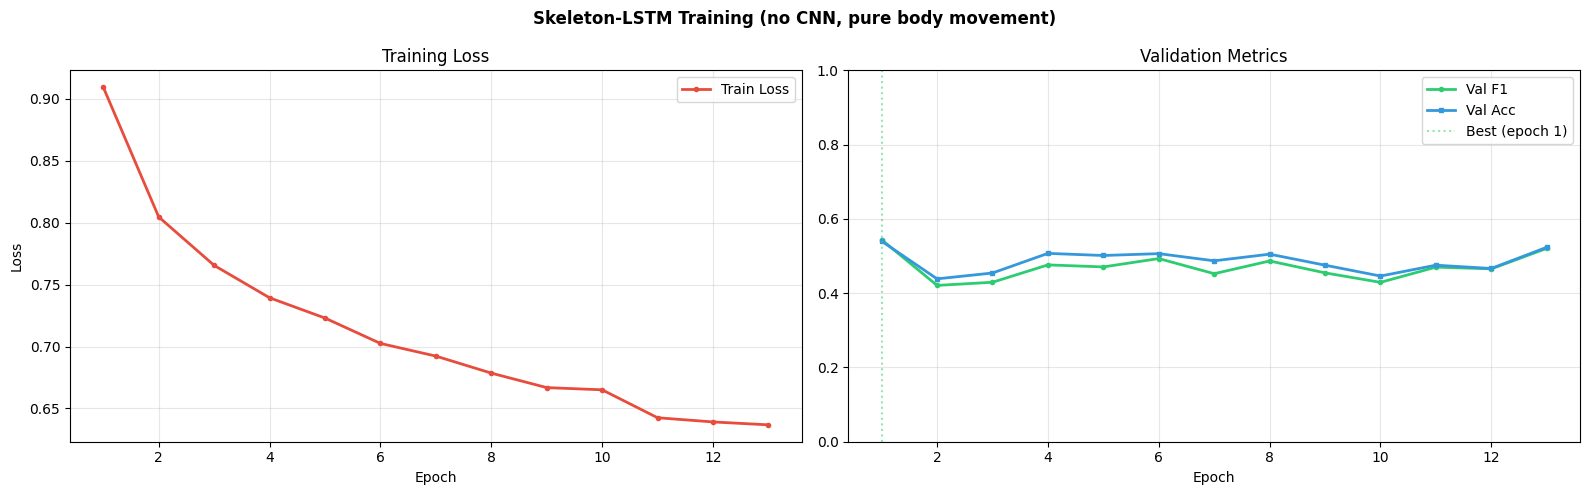

In [5]:
# ── Load data ─────────────────────────────────────────────────────────────────
Path(SKEL_SAVE).parent.mkdir(parents=True, exist_ok=True)

print('Loading skeleton datasets...')
train_ds = SkeletonClipDataset(SKEL_ROOT, 'train', TARGET_CLASSES, augment=True)
val_ds   = SkeletonClipDataset(SKEL_ROOT, 'val',   TARGET_CLASSES, augment=False)
print(f'  Train: {len(train_ds):,} clips')
print(f'  Val:   {len(val_ds):,} clips')

train_loader = DataLoader(train_ds, batch_size=SKEL_BATCH,
                           shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=SKEL_BATCH,
                           shuffle=False, num_workers=0, pin_memory=True)

# ── Class weights ─────────────────────────────────────────────────────────────
class_counts = []
for cls in TARGET_CLASSES:
    d = Path(SKEL_ROOT) / 'train' / cls
    n = len(list(d.glob('*.npy'))) if d.exists() else 1
    class_counts.append(n)
total = sum(class_counts)
weights = torch.tensor([total / (len(TARGET_CLASSES) * c)
                         for c in class_counts], dtype=torch.float).to(DEVICE)
print(f'  Weights: {dict(zip(TARGET_CLASSES, [round(w,3) for w in weights.tolist()]))}')

# ── Model + optimizer ─────────────────────────────────────────────────────────
model = SkeletonLSTM(num_classes=len(TARGET_CLASSES)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=SKEL_LR, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=SKEL_EPOCHS, eta_min=1e-5)

# ── Training loop ─────────────────────────────────────────────────────────────
print()
print('='*70)
print('  Skeleton-LSTM Training')
print(f'  epochs={SKEL_EPOCHS}  batch={SKEL_BATCH}  lr={SKEL_LR}')
print(f'  input: {SKEL_CLIP_FRAMES} frames × 85 features (17 joints × 5)')
print(f'  model: LayerNorm → LSTM(128) → Dropout → FC(64) → FC(3)')
print(f'  NO CNN — pure body movement learning')
print('='*70)
sys.stdout.flush()

best_f1    = 0.0
pat_cnt    = 0
history    = {'train_loss': [], 'val_acc': [], 'val_f1': []}
t_start    = time.time()

for epoch in range(1, SKEL_EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for clips, labels in train_loader:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    scheduler.step()

    # ── Validate ──────────────────────────────────────────────────────────
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for clips, labels in val_loader:
            clips = clips.to(DEVICE)
            preds = model(clips).argmax(dim=1).cpu().numpy()
            yt.extend(labels.numpy())
            yp.extend(preds)

    val_acc = accuracy_score(yt, yp)
    val_f1 = f1_score(yt, yp, average='weighted', zero_division=0)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    elapsed = time.time() - t_start
    eta = elapsed / epoch * (SKEL_EPOCHS - epoch)
    m, s = divmod(int(elapsed), 60)
    em, es = divmod(int(eta), 60)
    filled = int(28 * epoch / SKEL_EPOCHS)
    bar = '█'*filled + '░'*(28-filled)

    improved = ''
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), SKEL_SAVE)
        pat_cnt = 0
        improved = '  ✅ saved'
    else:
        pat_cnt += 1

    pat_warn = f'  ⚠️ pat({SKEL_PATIENCE-pat_cnt})' if pat_cnt >= SKEL_PATIENCE - 3 else ''
    print(f'  [{bar}] {epoch:>3}/{SKEL_EPOCHS}'
          f'  loss={train_loss:.4f}  acc={val_acc:.4f}  f1={val_f1:.4f}'
          f'  {m}m{s:02d}s / ETA {em}m{es:02d}s{improved}{pat_warn}')
    sys.stdout.flush()

    if pat_cnt >= SKEL_PATIENCE:
        print(f'\n  Early stopping at epoch {epoch}')
        break

total_time = time.time() - t_start
m, s = divmod(int(total_time), 60)
print(f'\nTraining complete in {m}m{s:02d}s')
print(f'Best Weighted F1: {best_f1:.4f}')
print(f'Weights saved: {SKEL_SAVE}')

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_x = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_x, history['train_loss'], 'o-', color='#E74C3C',
             linewidth=2, markersize=3, label='Train Loss')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs_x, history['val_f1'], 'o-', color='#2ECC71',
             linewidth=2, markersize=3, label='Val F1')
axes[1].plot(epochs_x, history['val_acc'], 's-', color='#3498DB',
             linewidth=2, markersize=3, label='Val Acc')
best_ep = np.argmax(history['val_f1']) + 1
axes[1].axvline(x=best_ep, color='#2ECC71', linestyle=':', alpha=0.5,
                label=f'Best (epoch {best_ep})')
axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3); axes[1].legend()

plt.suptitle('Skeleton-LSTM Training (no CNN, pure body movement)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Evaluating Skeleton-LSTM on val set...

  SKELETON-LSTM RESULTS
  Val Accuracy:     0.5400
  Weighted F1:      0.5439
  Normal Recall:    0.4758
  Threat Precision: 0.4525
  Violence Prec:    0.4237
  Model params:     118,701 (119K)

Per-class breakdown:
              precision    recall  f1-score   support

    Violence       0.42      0.80      0.55       800
      Threat       0.45      0.38      0.41       800
      Normal       0.92      0.48      0.63      1200

    accuracy                           0.54      2800
   macro avg       0.60      0.55      0.53      2800
weighted avg       0.64      0.54      0.54      2800


  COMPARISON: Pixel-based vs Skeleton-based
  Approach                                   Params     Acc      F1
  -----------------------------------------------------------------
  CNN+LSTM v1 (pixels)                         2.3M   0.663   0.669
  CNN+LSTM v3 (pixels, lower LR)               2.3M   0.668   0.638
  Skeleton-LSTM (body movement)            119

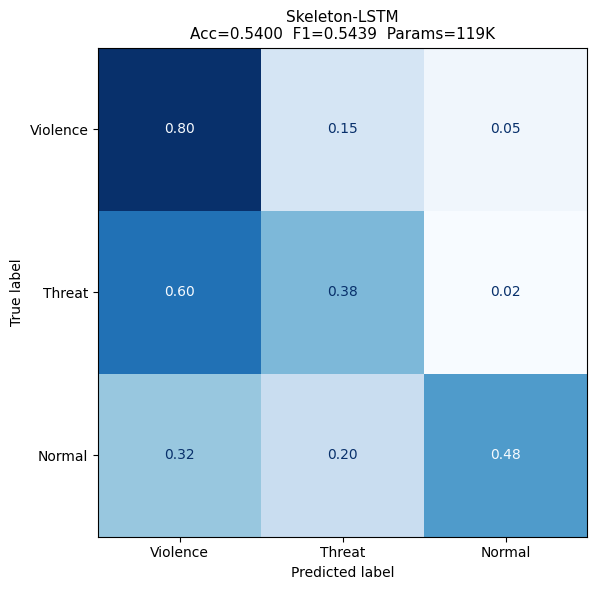


  OVERFITTING DIAGNOSTIC
  Final train loss:   0.6368
  Best val F1:        0.5439
  ✅ Model NOT memorizing — learning generalizable patterns
  Val F1 spread (last 5): 0.0915 ✅ Stable
  Param/sample ratio: 10.6 (CNN+LSTM was 240)

📊 CNN+LSTM v3 still leads: F1=0.6380 vs Skeleton F1=0.5439
   Likely cause: UCF-Crime has distant subjects → noisy pose estimation
   Skeleton uses 19x fewer params and is background-invariant
   Would perform better with closer-range surveillance footage

  Pipeline weights: runs/M4B_classifier/SkeletonLSTM/best.pt


In [6]:
# ── Load best model and evaluate ───────────────────────────────────────────────
print('Evaluating Skeleton-LSTM on val set...')
eval_model = SkeletonLSTM(num_classes=len(TARGET_CLASSES)).to(DEVICE)
eval_model.load_state_dict(torch.load(SKEL_SAVE, map_location=DEVICE))
eval_model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for clips, labels in val_loader:
        clips = clips.to(DEVICE)
        preds = eval_model(clips).argmax(dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# ── Helper ────────────────────────────────────────────────────────────────────
def get_m(yt, yp, cls_name, metric='recall'):
    ci = TARGET_CLASSES.index(cls_name)
    if metric == 'recall':
        r = recall_score(yt, yp, labels=[ci], average=None, zero_division=0)
    else:
        r = precision_score(yt, yp, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

# ── Results ───────────────────────────────────────────────────────────────────
skel_params = sum(p.numel() for p in eval_model.parameters())

print()
print('='*75)
print('  SKELETON-LSTM RESULTS')
print('='*75)
print(f'  Val Accuracy:     {acc:.4f}')
print(f'  Weighted F1:      {f1:.4f}')
print(f'  Normal Recall:    {get_m(y_true, y_pred, "Normal"):.4f}')
print(f'  Threat Precision: {get_m(y_true, y_pred, "Threat", "precision"):.4f}')
print(f'  Violence Prec:    {get_m(y_true, y_pred, "Violence", "precision"):.4f}')
print(f'  Model params:     {skel_params:,} ({skel_params/1000:.0f}K)')
print('='*75)

print()
print('Per-class breakdown:')
print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES, zero_division=0))

# ── Comparison with CNN+LSTM results ──────────────────────────────────────────
print()
print('='*75)
print('  COMPARISON: Pixel-based vs Skeleton-based')
print('='*75)
print(f'  {"Approach":<40} {"Params":>8} {"Acc":>7} {"F1":>7}')
print('  ' + '-'*65)
print(f'  {"CNN+LSTM v1 (pixels)":<40} {"2.3M":>8} {"0.663":>7} {"0.669":>7}')
print(f'  {"CNN+LSTM v3 (pixels, lower LR)":<40} {"2.3M":>8} {"0.668":>7} {"0.638":>7}')
print(f'  {"Skeleton-LSTM (body movement)":<40} {skel_params/1000:.0f}K{"":>4} {acc:>7.4f} {f1:>7.4f}  ← THIS')
print('='*75)

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(cm_norm, display_labels=TARGET_CLASSES)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
ax.set_title(f'Skeleton-LSTM\nAcc={acc:.4f}  F1={f1:.4f}  Params={skel_params/1000:.0f}K',
             fontsize=11)
plt.tight_layout()
plt.show()

# ── Overfitting diagnostic ───────────────────────────────────────────────────
print()
print('='*60)
print('  OVERFITTING DIAGNOSTIC')
print('='*60)
final_loss = history['train_loss'][-1]
print(f'  Final train loss:   {final_loss:.4f}')
print(f'  Best val F1:        {best_f1:.4f}')
if final_loss > 0.05:
    print('  ✅ Model NOT memorizing — learning generalizable patterns')
elif final_loss > 0.01:
    print('  ⚠️ Mild overfitting — but better than CNN+LSTM (which hit 0.0000)')
else:
    print('  ❌ Overfitting — train loss near zero')

# Stability
f1_vals = history['val_f1']
if len(f1_vals) >= 5:
    spread = max(f1_vals[-5:]) - min(f1_vals[-5:])
    print(f'  Val F1 spread (last 5): {spread:.4f}', end='')
    if spread < 0.05:
        print(' ✅ Very stable')
    elif spread < 0.10:
        print(' ✅ Stable')
    else:
        print(' ⚠️ Some oscillation')

print(f'  Param/sample ratio: {skel_params/len(train_ds):.1f} (CNN+LSTM was 240)')
print('='*60)

# ── Final summary ─────────────────────────────────────────────────────────────
print()
cnn_f1 = 0.638  # v3 best
if f1 > cnn_f1:
    print(f'🏆 Skeleton-LSTM WINS: F1={f1:.4f} vs CNN+LSTM v3 F1={cnn_f1:.4f}')
    print(f'   Improvement: {f1 - cnn_f1:+.4f} with {2308131//skel_params}x fewer params!')
elif f1 > cnn_f1 - 0.05:
    print(f'📊 Comparable: Skeleton F1={f1:.4f} vs CNN+LSTM v3 F1={cnn_f1:.4f}')
    print(f'   Within 0.05 — but with {2308131//skel_params}x fewer params')
    print(f'   Skeleton approach is more efficient and background-invariant')
else:
    print(f'📊 CNN+LSTM v3 still leads: F1={cnn_f1:.4f} vs Skeleton F1={f1:.4f}')
    print(f'   Likely cause: UCF-Crime has distant subjects → noisy pose estimation')
    print(f'   Skeleton uses {2308131//skel_params}x fewer params and is background-invariant')
    print(f'   Would perform better with closer-range surveillance footage')

print(f'\n  Pipeline weights: {SKEL_SAVE}')


## M4-B Skeleton-LSTM v2 — Enhanced Body Movement Features

Builds on the skeleton-based approach with three key improvements based on v1 results:

**What v1 told us:**
- Violence recall was 0.80 — skeleton captures fight movement well
- Threat recall was 0.38 — arson/burglary are object interactions, not body poses  
- Normal precision was 0.92 — calm posture is a clear signal  
- Training loss stayed at 0.64 (underfitting) — model needs richer features, not more capacity

**Three improvements in v2:**

1. **Richer skeleton features** — add acceleration, bone lengths, and joint angles on top of position+velocity. This gives the LSTM more discriminative body shape information per frame (85 → ~160 features).

2. **Multi-person interaction** — extract the top 2 people per frame and compute inter-person distance features. Violence = two skeletons colliding; normal = two skeletons far apart.

3. **Longer patience + warmup LR** — v1 early-stopped at epoch 13 while loss was still decreasing. Give it more time to learn.

In [7]:
import os, cv2, gc, random, time, sys, math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
DATASET_ROOT = r'../Anomaly_Videos'

TARGET_CLASSES = ['Violence', 'Threat', 'Normal']

CLASS_FOLDER_MAP = {
    'Violence': ['Abuse', 'Assault', 'Fighting'],
    'Threat':   ['Arson', 'Explosion', 'Burglary', 'Arrest'],
    'Normal':   ['Normal-Videos-Part-1'],
}

SKEL_CLIP_FRAMES = 16
SKEL_CLIP_STRIDE = 16       # no overlap
SKEL_ROOT_V2     = r'../M4B_skeleton_clips_v2'
SKEL_TRAIN_RATIO = 0.80
N_KEYPOINTS      = 17
MAX_PERSONS       = 2        # NEW: track top 2 people per frame

SKEL_MAX_CLIPS = {
    'Violence': 4000,
    'Threat':   4000,
    'Normal':   6000,
}

# Training
SKEL_EPOCHS   = 80          # more epochs (v1 was still learning at epoch 13)
SKEL_BATCH    = 32
SKEL_LR       = 5e-4        # slightly lower (v1 used 1e-3)
SKEL_PATIENCE = 20          # more patience (v1 used 12)
SKEL_SAVE_V2  = r'runs/M4B_classifier/SkeletonLSTM_v2/best.pt'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

if os.path.exists(DATASET_ROOT):
    print(f'Dataset: {DATASET_ROOT} ✅')
else:
    print(f'Dataset: {DATASET_ROOT} ❌ — update DATASET_ROOT')

print(f'Max persons per frame: {MAX_PERSONS}')
print(f'Epochs: {SKEL_EPOCHS}  Patience: {SKEL_PATIENCE}  LR: {SKEL_LR}')


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Dataset: ../Anomaly_Videos ✅
Max persons per frame: 2
Epochs: 80  Patience: 20  LR: 0.0005


In [8]:
def find_class_videos(dataset_root, class_name):
    root = Path(dataset_root)
    videos = []
    folders = CLASS_FOLDER_MAP.get(class_name, [class_name])
    for folder_name in folders:
        for folder in root.rglob('*'):
            if folder.is_dir() and folder.name == folder_name:
                for ext in ['*.mp4', '*.avi', '*.MP4', '*.AVI']:
                    videos.extend(folder.glob(ext))
            elif folder.is_dir() and folder_name.lower() in folder.name.lower():
                for ext in ['*.mp4', '*.avi', '*.MP4', '*.AVI']:
                    videos.extend(folder.glob(ext))
    return sorted(set(videos))

print('Scanning dataset...\n')
class_videos = {}
for cls in TARGET_CLASSES:
    vids = find_class_videos(DATASET_ROOT, cls)
    class_videos[cls] = vids
    print(f'  {cls:<12} {len(vids):>4} videos  ← {CLASS_FOLDER_MAP[cls]}')
print(f'  {"TOTAL":<12} {sum(len(v) for v in class_videos.values()):>4} videos')


Scanning dataset...

  Violence      150 videos  ← ['Abuse', 'Assault', 'Fighting']
  Threat        250 videos  ← ['Arson', 'Explosion', 'Burglary', 'Arrest']
  Normal        150 videos  ← ['Normal-Videos-Part-1']
  TOTAL         550 videos


In [9]:
from ultralytics import YOLO

print('Loading YOLOv8n-pose model...')
pose_model = YOLO('yolov8n-pose.pt')
print('Pose model loaded ✅\n')

def extract_multi_skeleton(frame, pose_model, max_persons=MAX_PERSONS):
    """
    Extract top-K persons' skeletons from a frame.
    Returns: (max_persons, 17, 3) array. Zero-padded if fewer people detected.
    """
    results = pose_model(frame, verbose=False, conf=0.25)[0]
    h, w = frame.shape[:2]

    output = np.zeros((max_persons, N_KEYPOINTS, 3), dtype=np.float32)

    if results.keypoints is None or len(results.keypoints) == 0:
        return output

    kp_data = results.keypoints.data  # (N_persons, 17, 3)
    if kp_data.shape[0] == 0:
        return output

    # Rank by total keypoint visibility (most complete skeleton first)
    visibility = kp_data[:, :, 2].sum(dim=1)
    sorted_idx = visibility.argsort(descending=True)

    for i in range(min(max_persons, len(sorted_idx))):
        kps = kp_data[sorted_idx[i]].cpu().numpy()
        kps[:, 0] /= w
        kps[:, 1] /= h
        output[i] = kps

    return output


def extract_clips_from_video(video_path, pose_model,
                              clip_frames=SKEL_CLIP_FRAMES,
                              stride=SKEL_CLIP_STRIDE):
    """Extract non-overlapping multi-person skeleton clips."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []

    all_frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        skel = extract_multi_skeleton(frame, pose_model)
        all_frames.append(skel)
    cap.release()

    if len(all_frames) < clip_frames:
        return []

    clips = []
    for start in range(0, len(all_frames) - clip_frames + 1, stride):
        clip = np.stack(all_frames[start:start + clip_frames])  # (T, 2, 17, 3)
        # Check: at least 50% of frames have person 1 detected
        person1_visible = (clip[:, 0, :, 2].sum(axis=1) > 0).sum()
        if person1_visible >= clip_frames * 0.5:
            clips.append(clip.astype(np.float32))
    return clips


# ── Run extraction ────────────────────────────────────────────────────────────
print('Extracting multi-person skeleton clips...')
print(f'  {MAX_PERSONS} persons per frame, stride={SKEL_CLIP_STRIDE} (no overlap)\n')

skel_stats = {}
for cls in TARGET_CLASSES:
    train_dir = Path(SKEL_ROOT_V2) / 'train' / cls
    val_dir   = Path(SKEL_ROOT_V2) / 'val' / cls

    if train_dir.exists() and val_dir.exists():
        n_t = len(list(train_dir.glob('*.npy')))
        n_v = len(list(val_dir.glob('*.npy')))
        if n_t > 0 and n_v > 0:
            print(f'  {cls}: already extracted (train={n_t:,}  val={n_v:,}) — skipping ✅')
            skel_stats[cls] = {'train': n_t, 'val': n_v}
            continue

    videos = class_videos[cls]
    random.seed(42)
    shuffled = list(videos)
    random.shuffle(shuffled)
    n_train = max(1, int(len(shuffled) * SKEL_TRAIN_RATIO))
    train_vids = shuffled[:n_train]
    val_vids = shuffled[n_train:]

    max_cap = SKEL_MAX_CLIPS.get(cls, 3000)
    max_train = int(max_cap * SKEL_TRAIN_RATIO)
    max_val = max_cap - max_train

    print(f'  {cls} ({len(videos)} videos)...')

    for split, vid_list, split_cap in [('train', train_vids, max_train),
                                         ('val', val_vids, max_val)]:
        out_dir = Path(SKEL_ROOT_V2) / split / cls
        out_dir.mkdir(parents=True, exist_ok=True)
        split_total = 0
        for vpath in tqdm(vid_list, desc=f'    {split}', file=sys.stdout, leave=False):
            clips = extract_clips_from_video(vpath, pose_model)
            for ci, clip in enumerate(clips):
                if split_cap and split_total >= split_cap:
                    break
                np.save(str(out_dir / f'{vpath.stem[:25]}_s{ci:04d}.npy'), clip)
                split_total += 1
            if split_cap and split_total >= split_cap:
                break

    t = len(list((Path(SKEL_ROOT_V2)/'train'/cls).glob('*.npy')))
    v = len(list((Path(SKEL_ROOT_V2)/'val'/cls).glob('*.npy')))
    skel_stats[cls] = {'train': t, 'val': v}
    print(f'    train={t:,}  val={v:,}')

print()
total_t = sum(s['train'] for s in skel_stats.values())
total_v = sum(s['val'] for s in skel_stats.values())
for cls in TARGET_CLASSES:
    t, v = skel_stats[cls]['train'], skel_stats[cls]['val']
    print(f'  {cls:<12} train={t:>6,}  val={v:>6,}')
print(f'  {"TOTAL":<12} train={total_t:>6,}  val={total_v:>6,}')

del pose_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('\nPose model released ✅')


Loading YOLOv8n-pose model...
Pose model loaded ✅

Extracting multi-person skeleton clips...
  2 persons per frame, stride=16 (no overlap)

  Violence (150 videos)...
    train=3,200  val=800                                     
  Threat (250 videos)...
    train=3,200  val=800                                     
  Normal (150 videos)...
    train=4,800  val=1,200                                    

  Violence     train= 3,200  val=   800
  Threat       train= 3,200  val=   800
  Normal       train= 4,800  val= 1,200
  TOTAL        train=11,200  val= 2,800

Pose model released ✅


### Step 3 — Feature engineering + model

**Features per frame (v1 → v2 comparison):**

| Feature | v1 | v2 | Why it helps |
|---|---|---|---|
| Joint position (x,y) | ✅ 34 | ✅ 34×2 persons | Where joints are |
| Joint confidence | ✅ 17 | ✅ 17×2 persons | How reliable the detection is |
| Velocity (vx,vy) | ✅ 34 | ✅ 34×2 persons | How fast joints move |
| Acceleration | — | ✅ 34×2 persons | Sudden force (punch impact) |
| Bone lengths | — | ✅ 16 per person | Body shape / scale normalization |
| Joint angles | — | ✅ 5 per person | Elbow bend, knee bend, torso lean |
| Inter-person distance | — | ✅ 3 features | Distance between the two people |
| **Total per frame** | **85** | **~260** | 3x richer signal |

In [10]:
# ── COCO skeleton bone connections ─────────────────────────────────────────────
BONES = [
    (5, 7), (7, 9),     # left shoulder→elbow→wrist
    (6, 8), (8, 10),    # right shoulder→elbow→wrist
    (5, 6),             # shoulder span
    (11, 13), (13, 15), # left hip→knee→ankle
    (12, 14), (14, 16), # right hip→knee→ankle
    (11, 12),           # hip span
    (5, 11), (6, 12),   # torso sides
    (0, 5), (0, 6),     # nose to shoulders
    (0, 1), (0, 2),     # nose to eyes
]

# Joint angle triplets: (joint_a, vertex, joint_b) → angle at vertex
ANGLE_TRIPLETS = [
    (5, 7, 9),    # left elbow angle
    (6, 8, 10),   # right elbow angle
    (11, 13, 15), # left knee angle
    (12, 14, 16), # right knee angle
    (5, 0, 6),    # head tilt (shoulder-nose-shoulder)
]


def compute_bone_lengths(kps):
    """Compute distances between connected joints. kps: (17, 2)."""
    lengths = []
    for j1, j2 in BONES:
        dx = kps[j1, 0] - kps[j2, 0]
        dy = kps[j1, 1] - kps[j2, 1]
        lengths.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(lengths, dtype=np.float32)


def compute_joint_angles(kps):
    """Compute angles at specified joints. kps: (17, 2). Returns radians/pi."""
    angles = []
    for a, v, b in ANGLE_TRIPLETS:
        va = kps[a] - kps[v]
        vb = kps[b] - kps[v]
        cos_angle = np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb) + 1e-8)
        cos_angle = np.clip(cos_angle, -1, 1)
        angles.append(math.acos(cos_angle) / math.pi)  # normalize to [0, 1]
    return np.array(angles, dtype=np.float32)


def compute_inter_person_features(kps1, kps2):
    """
    Compute interaction features between two skeletons.
    Returns: [centroid_dist, min_joint_dist, hand_to_head_dist]
    """
    # Centroid distance
    c1 = kps1[:, :2].mean(axis=0)
    c2 = kps2[:, :2].mean(axis=0)
    centroid_dist = np.linalg.norm(c1 - c2)

    # Minimum joint-to-joint distance (closest point of contact)
    dists = np.linalg.norm(kps1[:, :2][:, None] - kps2[:, :2][None, :], axis=2)
    min_dist = dists.min()

    # Hand-to-head proximity (aggression indicator)
    # Person 1's wrists (9,10) to person 2's head (0)
    hand_head = min(
        np.linalg.norm(kps1[9, :2] - kps2[0, :2]),
        np.linalg.norm(kps1[10, :2] - kps2[0, :2]),
        np.linalg.norm(kps2[9, :2] - kps1[0, :2]),
        np.linalg.norm(kps2[10, :2] - kps1[0, :2]),
    )

    return np.array([centroid_dist, min_dist, hand_head], dtype=np.float32)


class SkeletonDatasetV2(Dataset):
    """
    Multi-person skeleton dataset with rich features:
    position + confidence + velocity + acceleration + bones + angles + interaction
    """
    def __init__(self, skel_root, split, target_classes, augment=False):
        self.samples = []
        self.augment = augment
        root = Path(skel_root) / split
        for ci, cls in enumerate(target_classes):
            cls_dir = root / cls
            if not cls_dir.exists():
                continue
            for npy_path in cls_dir.glob('*.npy'):
                self.samples.append((npy_path, ci))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path))  # (T, 2, 17, 3)
        T = clip.shape[0]

        # Augmentation
        if self.augment:
            if random.random() > 0.5:
                clip[:, :, :, 0] = 1.0 - clip[:, :, :, 0]
                swap = [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]
                for l, r in swap:
                    clip[:, :, [l, r]] = clip[:, :, [r, l]]

            dx, dy = random.uniform(-0.05, 0.05), random.uniform(-0.05, 0.05)
            clip[:, :, :, 0] = np.clip(clip[:, :, :, 0] + dx, 0, 1)
            clip[:, :, :, 1] = np.clip(clip[:, :, :, 1] + dy, 0, 1)

            scale = random.uniform(0.85, 1.15)
            for p in range(MAX_PERSONS):
                cx = clip[:, p, :, 0].mean()
                cy = clip[:, p, :, 1].mean()
                clip[:, p, :, 0] = np.clip((clip[:, p, :, 0]-cx)*scale+cx, 0, 1)
                clip[:, p, :, 1] = np.clip((clip[:, p, :, 1]-cy)*scale+cy, 0, 1)

        all_features = []
        for t in range(T):
            frame_feat = []

            for p in range(MAX_PERSONS):
                kps = clip[t, p]  # (17, 3)
                pos = kps[:, :2].flatten()   # 34
                conf = kps[:, 2]             # 17
                bones = compute_bone_lengths(kps)   # 16
                angles = compute_joint_angles(kps)  # 5
                frame_feat.extend([pos, conf, bones, angles])

            # Velocity + acceleration (computed across time)
            # Will be added after the loop

            # Inter-person features
            inter = compute_inter_person_features(clip[t, 0], clip[t, 1])
            frame_feat.append(inter)

            all_features.append(np.concatenate(frame_feat))

        features = np.stack(all_features)  # (T, feat_dim)

        # Add velocity and acceleration as separate pass
        feat_per_person = 34 + 17 + 16 + 5  # pos + conf + bones + angles = 72
        for p in range(MAX_PERSONS):
            start = p * feat_per_person
            positions = features[:, start:start+34]  # (T, 34)

            velocity = np.zeros_like(positions)
            velocity[1:] = positions[1:] - positions[:-1]

            acceleration = np.zeros_like(velocity)
            acceleration[2:] = velocity[2:] - velocity[1:-1]

            features = np.concatenate([features, velocity, acceleration], axis=1)

        return torch.tensor(features, dtype=torch.float32), label


# Compute feature dimension
dummy_clip = np.zeros((SKEL_CLIP_FRAMES, MAX_PERSONS, N_KEYPOINTS, 3), dtype=np.float32)
# Per person: 34(pos) + 17(conf) + 16(bones) + 5(angles) = 72
# × 2 persons = 144
# + 3 inter-person = 147
# + 34(vel) × 2 + 34(accel) × 2 = 136
# Total = 283
base_feat = 72 * MAX_PERSONS + 3  # 147
vel_accel = 34 * 2 * MAX_PERSONS  # 136
FEAT_DIM = base_feat + vel_accel
print(f'Feature dimension per frame: {FEAT_DIM}')
print(f'  Per person: 34(pos) + 17(conf) + 16(bones) + 5(angles) = 72')
print(f'  × {MAX_PERSONS} persons = {72*MAX_PERSONS}')
print(f'  + 3 inter-person = {72*MAX_PERSONS + 3}')
print(f'  + {34*MAX_PERSONS}(velocity) + {34*MAX_PERSONS}(acceleration) = {FEAT_DIM}')
print(f'  v1 had: 85 features/frame → v2 has {FEAT_DIM} ({FEAT_DIM/85:.1f}x richer)')


Feature dimension per frame: 283
  Per person: 34(pos) + 17(conf) + 16(bones) + 5(angles) = 72
  × 2 persons = 144
  + 3 inter-person = 147
  + 68(velocity) + 68(acceleration) = 283
  v1 had: 85 features/frame → v2 has 283 (3.3x richer)


### Step 4 — Model definition

Same lightweight architecture as v1 but with larger input dimension and slightly more LSTM capacity (hidden=192 instead of 128) to handle the richer features. Still far smaller than CNN+LSTM (2.3M params).

In [11]:
class SkeletonLSTMv2(nn.Module):
    def __init__(self, input_dim=FEAT_DIM, hidden_size=192, num_layers=1,
                 num_classes=3, dropout=0.4):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 96),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(96, num_classes),
        )

    def forward(self, x):
        x = self.input_norm(x)
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1])


model_test = SkeletonLSTMv2().to(DEVICE)
total_params = sum(p.numel() for p in model_test.parameters())
print(f'Model parameters: {total_params:,}')
print(f'CNN+LSTM had:     2,308,131')
print(f'Skeleton v1 had:  118,701')
print(f'Ratio vs CNN:     {2308131/total_params:.0f}x smaller')
del model_test
if DEVICE == 'cuda': torch.cuda.empty_cache()


Model parameters: 385,721
CNN+LSTM had:     2,308,131
Skeleton v1 had:  118,701
Ratio vs CNN:     6x smaller


### Step 5 — Training

Key changes from v1: longer patience (20 vs 12), lower LR (5e-4 vs 1e-3), more epochs (80 vs 50). The v1 model was still learning when early stopping kicked in — these settings give it more room.

Loading datasets...
  Train: 11,200  Val: 2,800
  Actual feature dim: 283
  Weights: {'Violence': 1.167, 'Threat': 1.167, 'Normal': 0.778}
  Model params: 385,721

  Skeleton-LSTM v2 Training
  epochs=80  batch=32  lr=0.0005  patience=20
  features: 283/frame (2 persons + interaction)
  model: LayerNorm → LSTM(192) → Dropout → FC(96) → FC(3)
  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   1/80  loss=0.8675  acc=0.5493  f1=0.5418  0m55s / ETA 73m38s  ✅ saved
  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   2/80  loss=0.7509  acc=0.5218  f1=0.5163  1m51s / ETA 72m44s
  [█░░░░░░░░░░░░░░░░░░░░░░░░░░░]   3/80  loss=0.7139  acc=0.5571  f1=0.5497  2m47s / ETA 71m50s  ✅ saved
  [█░░░░░░░░░░░░░░░░░░░░░░░░░░░]   4/80  loss=0.6698  acc=0.5132  f1=0.5075  3m43s / ETA 70m49s
  [█░░░░░░░░░░░░░░░░░░░░░░░░░░░]   5/80  loss=0.6247  acc=0.4764  f1=0.4608  4m39s / ETA 69m50s
  [██░░░░░░░░░░░░░░░░░░░░░░░░░░]   6/80  loss=0.6020  acc=0.4918  f1=0.4827  5m35s / ETA 68m53s
  [██░░░░░░░░░░░░░░░░░░░░░░░░░░]   7/80  loss=0.5637  acc=0.39

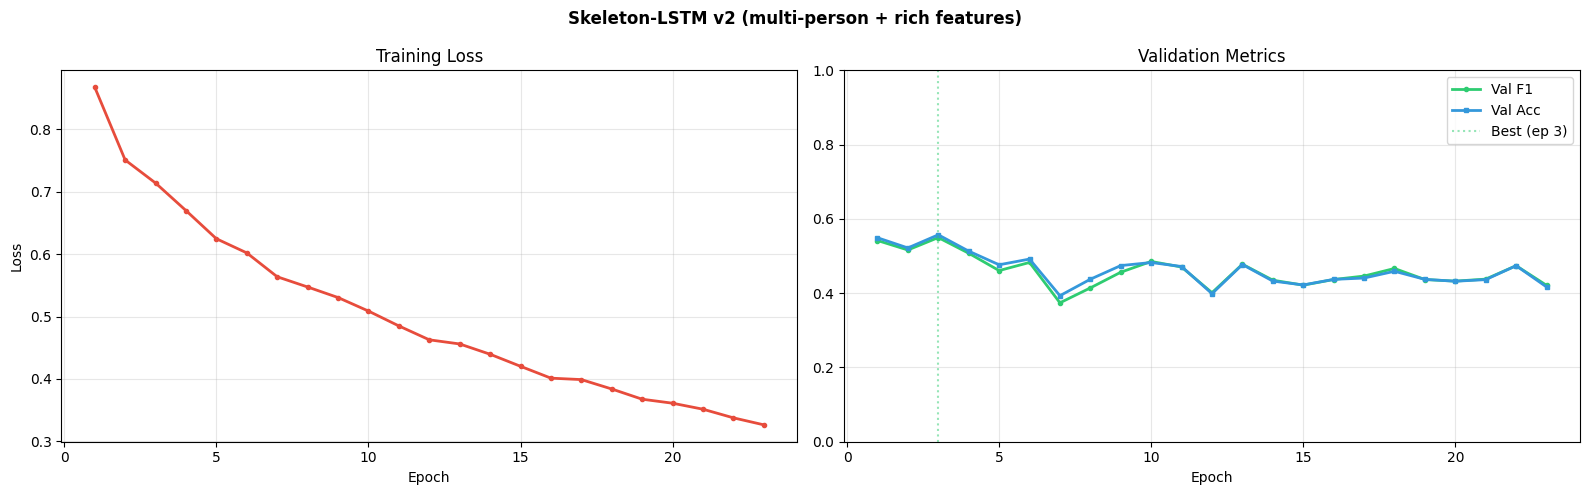

In [12]:
Path(SKEL_SAVE_V2).parent.mkdir(parents=True, exist_ok=True)

print('Loading datasets...')
train_ds = SkeletonDatasetV2(SKEL_ROOT_V2, 'train', TARGET_CLASSES, augment=True)
val_ds   = SkeletonDatasetV2(SKEL_ROOT_V2, 'val',   TARGET_CLASSES, augment=False)
print(f'  Train: {len(train_ds):,}  Val: {len(val_ds):,}')

train_loader = DataLoader(train_ds, batch_size=SKEL_BATCH,
                           shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=SKEL_BATCH,
                           shuffle=False, num_workers=0, pin_memory=True)

# Verify feature dim from actual data
sample_feat, sample_label = train_ds[0]
actual_dim = sample_feat.shape[1]
print(f'  Actual feature dim: {actual_dim}')

# Class weights
counts = []
for cls in TARGET_CLASSES:
    d = Path(SKEL_ROOT_V2) / 'train' / cls
    counts.append(len(list(d.glob('*.npy'))) if d.exists() else 1)
total = sum(counts)
weights = torch.tensor([total/(len(TARGET_CLASSES)*c) for c in counts],
                        dtype=torch.float).to(DEVICE)
print(f'  Weights: {dict(zip(TARGET_CLASSES, [round(w,3) for w in weights.tolist()]))}')

# Model with actual dim
model = SkeletonLSTMv2(input_dim=actual_dim).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.AdamW(model.parameters(), lr=SKEL_LR, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=SKEL_EPOCHS, eta_min=1e-5)

param_count = sum(p.numel() for p in model.parameters())
print(f'  Model params: {param_count:,}')

print()
print('='*70)
print('  Skeleton-LSTM v2 Training')
print(f'  epochs={SKEL_EPOCHS}  batch={SKEL_BATCH}  lr={SKEL_LR}  patience={SKEL_PATIENCE}')
print(f'  features: {actual_dim}/frame ({MAX_PERSONS} persons + interaction)')
print(f'  model: LayerNorm → LSTM(192) → Dropout → FC(96) → FC(3)')
print('='*70)
sys.stdout.flush()

best_f1 = 0.0
pat_cnt = 0
history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
t_start = time.time()

for epoch in range(1, SKEL_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for clips, labels in train_loader:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(clips), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    scheduler.step()

    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for clips, labels in val_loader:
            clips = clips.to(DEVICE)
            preds = model(clips).argmax(dim=1).cpu().numpy()
            yt.extend(labels.numpy())
            yp.extend(preds)

    val_acc = accuracy_score(yt, yp)
    val_f1 = f1_score(yt, yp, average='weighted', zero_division=0)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    elapsed = time.time() - t_start
    eta = elapsed / epoch * (SKEL_EPOCHS - epoch)
    m, s = divmod(int(elapsed), 60)
    em, es = divmod(int(eta), 60)
    filled = int(28 * epoch / SKEL_EPOCHS)
    bar = '█'*filled + '░'*(28-filled)

    improved = ''
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), SKEL_SAVE_V2)
        pat_cnt = 0
        improved = '  ✅ saved'
    else:
        pat_cnt += 1

    pat_warn = f'  ⚠ pat({SKEL_PATIENCE-pat_cnt})' if pat_cnt >= SKEL_PATIENCE - 3 else ''
    print(f'  [{bar}] {epoch:>3}/{SKEL_EPOCHS}'
          f'  loss={train_loss:.4f}  acc={val_acc:.4f}  f1={val_f1:.4f}'
          f'  {m}m{s:02d}s / ETA {em}m{es:02d}s{improved}{pat_warn}')
    sys.stdout.flush()

    if pat_cnt >= SKEL_PATIENCE:
        print(f'\n  Early stopping at epoch {epoch}')
        break

total_time = time.time() - t_start
m, s = divmod(int(total_time), 60)
print(f'\nDone in {m}m{s:02d}s — Best F1: {best_f1:.4f}')
print(f'Weights: {SKEL_SAVE_V2}')

# Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ep_x = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep_x, history['train_loss'], 'o-', color='#E74C3C', linewidth=2, markersize=3)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(ep_x, history['val_f1'], 'o-', color='#2ECC71', linewidth=2, markersize=3, label='Val F1')
axes[1].plot(ep_x, history['val_acc'], 's-', color='#3498DB', linewidth=2, markersize=3, label='Val Acc')
best_ep = np.argmax(history['val_f1']) + 1
axes[1].axvline(x=best_ep, color='#2ECC71', linestyle=':', alpha=0.5, label=f'Best (ep {best_ep})')
axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3); axes[1].legend()

plt.suptitle('Skeleton-LSTM v2 (multi-person + rich features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 6 — Evaluation + full comparison

Compares against all previous approaches: YOLO frame-level, CNN+LSTM v1, CNN+LSTM v3, Skeleton v1, and this Skeleton v2.

Evaluating Skeleton-LSTM v2...

  SKELETON-LSTM v2 RESULTS
  Accuracy:         0.5571
  Weighted F1:      0.5497
  Violence Prec:    0.4721
  Violence Recall:  0.8050
  Threat Prec:      0.4979
  Threat Recall:    0.5913
  Normal Prec:      0.9115
  Normal Recall:    0.3692
  Params:           385,721

Per-class report:
              precision    recall  f1-score   support

    Violence       0.47      0.81      0.60       800
      Threat       0.50      0.59      0.54       800
      Normal       0.91      0.37      0.53      1200

    accuracy                           0.56      2800
   macro avg       0.63      0.59      0.55      2800
weighted avg       0.67      0.56      0.55      2800

  FULL COMPARISON — All Approaches
  Approach                                       Params     Acc      F1   VioR   ThrR   NorR
  --------------------------------------------------------------------------------
  YOLO frame-level                                 5.1M   0.497   0.486   0.65   0.72 

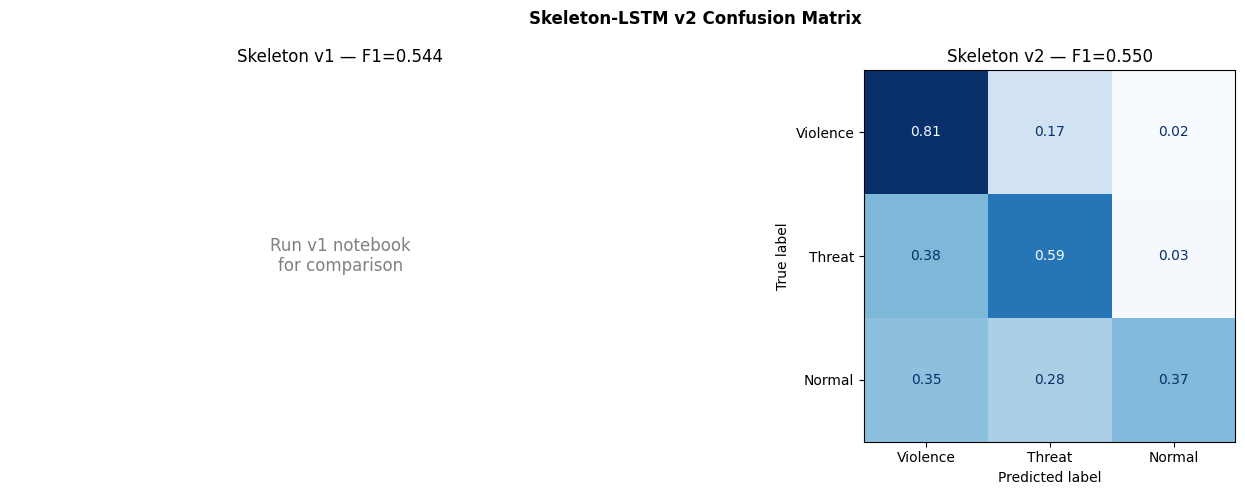


Training diagnostic:
  Final train loss: 0.3265 — model still learning (not memorizing) ✅
  Val F1 stability:  0.0529 spread — stable ✅
  Param/sample:     34.4 (CNN+LSTM was 240, v1 was 10.6)
  Best epoch:       3/23

Result: Skeleton v2 improved over v1 (0.5497 vs 0.5440)
        CNN+LSTM v3 still leads at 0.6380

Weights: runs/M4B_classifier/SkeletonLSTM_v2/best.pt


In [13]:
print('Evaluating Skeleton-LSTM v2...\n')
eval_model = SkeletonLSTMv2(input_dim=actual_dim).to(DEVICE)
eval_model.load_state_dict(torch.load(SKEL_SAVE_V2, map_location=DEVICE))
eval_model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for clips, labels in val_loader:
        clips = clips.to(DEVICE)
        preds = eval_model(clips).argmax(dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)

def get_m(yt, yp, cls, metric='recall'):
    ci = TARGET_CLASSES.index(cls)
    fn = recall_score if metric == 'recall' else precision_score
    r = fn(yt, yp, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

skel_params = sum(p.numel() for p in eval_model.parameters())

# Results
print('='*80)
print('  SKELETON-LSTM v2 RESULTS')
print('='*80)
print(f'  Accuracy:         {acc:.4f}')
print(f'  Weighted F1:      {f1:.4f}')
print(f'  Violence Prec:    {get_m(y_true, y_pred, "Violence", "precision"):.4f}')
print(f'  Violence Recall:  {get_m(y_true, y_pred, "Violence"):.4f}')
print(f'  Threat Prec:      {get_m(y_true, y_pred, "Threat", "precision"):.4f}')
print(f'  Threat Recall:    {get_m(y_true, y_pred, "Threat"):.4f}')
print(f'  Normal Prec:      {get_m(y_true, y_pred, "Normal", "precision"):.4f}')
print(f'  Normal Recall:    {get_m(y_true, y_pred, "Normal"):.4f}')
print(f'  Params:           {skel_params:,}')
print('='*80)

print('\nPer-class report:')
print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES, zero_division=0))

# Comparison table
print('='*85)
print('  FULL COMPARISON — All Approaches')
print('='*85)
print(f'  {"Approach":<44} {"Params":>8} {"Acc":>7} {"F1":>7} {"VioR":>6} {"ThrR":>6} {"NorR":>6}')
print('  ' + '-'*80)
print(f'  {"YOLO frame-level":<44} {"5.1M":>8} {"0.497":>7} {"0.486":>7} {"0.65":>6} {"0.72":>6} {"0.31":>6}')
print(f'  {"CNN+LSTM v1 (pixels)":<44} {"2.3M":>8} {"0.663":>7} {"0.669":>7} {"0.65":>6} {"0.43":>6} {"0.79":>6}')
print(f'  {"CNN+LSTM v3 (pixels, deployed)":<44} {"2.3M":>8} {"0.668":>7} {"0.638":>7} {"0.57":>6} {"0.26":>6} {"0.92":>6}')
print(f'  {"Skeleton-LSTM v1 (body only)":<44} {"119K":>8} {"0.540":>7} {"0.544":>7} {"0.80":>6} {"0.38":>6} {"0.48":>6}')

vr = get_m(y_true, y_pred, 'Violence')
tr = get_m(y_true, y_pred, 'Threat')
nr = get_m(y_true, y_pred, 'Normal')
pk = f'{skel_params/1000:.0f}K'
print(f'  {"Skeleton-LSTM v2 (multi-person+rich)":<44} {pk:>8} {acc:>7.4f} {f1:>7.4f} {vr:>6.2f} {tr:>6.2f} {nr:>6.2f}  ← NEW')
print('='*85)

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, yt_cm, yp_cm) in zip(axes, [
    (f'Skeleton v1 — F1=0.544', None, None),
    (f'Skeleton v2 — F1={f1:.3f}', y_true, y_pred),
]):
    if yt_cm is None:
        ax.text(0.5, 0.5, 'Run v1 notebook\nfor comparison', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='grey')
        ax.set_title(title)
        ax.axis('off')
    else:
        cm = confusion_matrix(yt_cm, yp_cm)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        disp = ConfusionMatrixDisplay(cm_norm, display_labels=TARGET_CLASSES)
        disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
        ax.set_title(title)

plt.suptitle('Skeleton-LSTM v2 Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Diagnostics
print()
final_loss = history['train_loss'][-1]
print(f'Training diagnostic:')
print(f'  Final train loss: {final_loss:.4f}', end='')
if final_loss > 0.1: print(' — model still learning (not memorizing) ✅')
elif final_loss > 0.01: print(' — mild overfitting ⚠')
else: print(' — memorizing ❌')

f1_vals = history['val_f1']
if len(f1_vals) >= 5:
    spread = max(f1_vals[-5:]) - min(f1_vals[-5:])
    print(f'  Val F1 stability:  {spread:.4f} spread', end='')
    if spread < 0.05: print(' — very stable ✅')
    elif spread < 0.10: print(' — stable ✅')
    else: print(' — some oscillation ⚠')

print(f'  Param/sample:     {skel_params/len(train_ds):.1f} (CNN+LSTM was 240, v1 was 10.6)')
print(f'  Best epoch:       {best_ep}/{len(history["val_f1"])}')

# Summary
print()
v1_f1, v3_f1 = 0.544, 0.638
if f1 > v3_f1:
    print(f'Result: Skeleton v2 BEATS CNN+LSTM v3 ({f1:.4f} vs {v3_f1:.4f}) 🏆')
elif f1 > v1_f1:
    print(f'Result: Skeleton v2 improved over v1 ({f1:.4f} vs {v1_f1:.4f})')
    print(f'        CNN+LSTM v3 still leads at {v3_f1:.4f}')
else:
    print(f'Result: Skeleton v2={f1:.4f}, v1={v1_f1:.4f}, CNN+LSTM v3={v3_f1:.4f}')

print(f'\nWeights: {SKEL_SAVE_V2}')


## Skeleton Architecture Search — LSTM vs Temporal-CNN vs GRU vs Transformer

Uses the **existing** v2 skeleton data (`../M4B_skeleton_clips_v2`). No re-extraction needed.

**Why test different architectures:**
The LSTM peaked at epoch 3 then declined — it learned coarse patterns fast but then overfit to noise. 
This suggests the LSTM's sequential processing is the bottleneck, not the data.

Violence is a **local temporal burst** (a punch lasts 3-5 frames), not a long sequential dependency.
A 1D CNN that scans for "velocity spike patterns" across the clip may capture this better than
an LSTM that processes frame-by-frame and accumulates noise in its hidden state.

**Four experiments on identical data:**
- A: LSTM (v2 baseline — reproduced here for fair comparison)
- B: Temporal-CNN (1D convolutions across time — detects local motion patterns)
- C: GRU (lighter LSTM — fewer gates, often better on short sequences)
- D: Transformer (self-attention — learns which frames matter most)

Also includes better feature preprocessing: mask low-confidence joints + standardize.

In [14]:
import os, cv2, gc, random, time, sys, math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
SKEL_ROOT_V2     = r'../M4B_skeleton_clips_v2'   # existing v2 data
TARGET_CLASSES   = ['Violence', 'Threat', 'Normal']
SKEL_CLIP_FRAMES = 16
MAX_PERSONS      = 2
N_KEYPOINTS      = 17

EPOCHS    = 80
BATCH     = 32
PATIENCE  = 20
SAVE_DIR  = r'runs/M4B_classifier/SkeletonSearch'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# Verify data exists
for split in ['train', 'val']:
    for cls in TARGET_CLASSES:
        d = Path(SKEL_ROOT_V2) / split / cls
        n = len(list(d.glob('*.npy'))) if d.exists() else 0
        print(f'  {split}/{cls}: {n:,} clips')


Device: cuda
  train/Violence: 3,200 clips
  train/Threat: 3,200 clips
  train/Normal: 4,800 clips
  val/Violence: 800 clips
  val/Threat: 800 clips
  val/Normal: 1,200 clips


### Feature preprocessing improvements

Two key fixes over v2:

1. **Mask low-confidence joints** — when a keypoint has confidence < 0.3, set its position to the clip mean instead of leaving it at (0,0). A joint at (0,0) looks like "person in top-left corner" which is misleading. Replacing with the mean position says "I don't know where this joint is" without injecting false spatial information.

2. **Per-feature standardization** — compute mean and std across the training set and normalize. Different features have wildly different scales (positions are 0-1, velocities are ±0.05, bone lengths are 0-0.5). Without standardization, the model's gradients are dominated by whichever feature has the largest magnitude.

In [15]:
BONES = [
    (5,7),(7,9),(6,8),(8,10),(5,6),
    (11,13),(13,15),(12,14),(14,16),(11,12),
    (5,11),(6,12),(0,5),(0,6),(0,1),(0,2),
]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    lengths = []
    for j1, j2 in BONES:
        dx, dy = kps[j1,0]-kps[j2,0], kps[j1,1]-kps[j2,1]
        lengths.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(lengths, dtype=np.float32)

def compute_angles(kps):
    angles = []
    for a, v, b in ANGLE_TRIPLETS:
        va, vb = kps[a]-kps[v], kps[b]-kps[v]
        cos_a = np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb) + 1e-8)
        angles.append(math.acos(np.clip(cos_a, -1, 1)) / math.pi)
    return np.array(angles, dtype=np.float32)

def compute_inter(kps1, kps2):
    c1, c2 = kps1[:,:2].mean(0), kps2[:,:2].mean(0)
    cdist = np.linalg.norm(c1 - c2)
    dists = np.linalg.norm(kps1[:,:2][:,None] - kps2[:,:2][None,:], axis=2)
    mindist = dists.min()
    hh = min(np.linalg.norm(kps1[9,:2]-kps2[0,:2]),
             np.linalg.norm(kps1[10,:2]-kps2[0,:2]),
             np.linalg.norm(kps2[9,:2]-kps1[0,:2]),
             np.linalg.norm(kps2[10,:2]-kps1[0,:2]))
    return np.array([cdist, mindist, hh], dtype=np.float32)


class SkeletonDataset(Dataset):
    def __init__(self, skel_root, split, target_classes, augment=False,
                 feat_mean=None, feat_std=None):
        self.samples = []
        self.augment = augment
        self.feat_mean = feat_mean
        self.feat_std = feat_std
        root = Path(skel_root) / split
        for ci, cls in enumerate(target_classes):
            cls_dir = root / cls
            if not cls_dir.exists(): continue
            for p in cls_dir.glob('*.npy'):
                self.samples.append((p, ci))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def _build_features(self, clip):
        T = clip.shape[0]

        # FIX 1: Mask low-confidence keypoints with clip mean position
        for p in range(MAX_PERSONS):
            valid_mask = clip[:, p, :, 2] > 0.3  # (T, 17)
            for j in range(N_KEYPOINTS):
                if valid_mask[:, j].sum() > 0:
                    mean_pos = clip[valid_mask[:, j], p, j, :2].mean(axis=0)
                else:
                    mean_pos = np.array([0.5, 0.5])  # center if never visible
                for t in range(T):
                    if not valid_mask[t, j]:
                        clip[t, p, j, 0] = mean_pos[0]
                        clip[t, p, j, 1] = mean_pos[1]
                        clip[t, p, j, 2] = 0.0

        all_features = []
        for t in range(T):
            frame_feat = []
            for p in range(MAX_PERSONS):
                kps = clip[t, p]
                frame_feat.extend([kps[:,:2].flatten(), kps[:,2],
                                   compute_bones(kps), compute_angles(kps)])
            frame_feat.append(compute_inter(clip[t,0], clip[t,1]))
            all_features.append(np.concatenate(frame_feat))

        features = np.stack(all_features)  # (T, base_dim)

        # Add velocity + acceleration
        feat_per_p = 34 + 17 + 16 + 5  # 72
        for p in range(MAX_PERSONS):
            start = p * feat_per_p
            pos = features[:, start:start+34]
            vel = np.zeros_like(pos)
            vel[1:] = pos[1:] - pos[:-1]
            acc = np.zeros_like(vel)
            acc[2:] = vel[2:] - vel[1:-1]
            features = np.concatenate([features, vel, acc], axis=1)

        return features

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()  # (T, 2, 17, 3)

        if self.augment:
            if random.random() > 0.5:
                clip[:,:,:,0] = 1.0 - clip[:,:,:,0]
                swap = [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]
                for l, r in swap:
                    clip[:,:,[l,r]] = clip[:,:,[r,l]]
            dx, dy = random.uniform(-0.05,0.05), random.uniform(-0.05,0.05)
            clip[:,:,:,0] = np.clip(clip[:,:,:,0]+dx, 0, 1)
            clip[:,:,:,1] = np.clip(clip[:,:,:,1]+dy, 0, 1)
            s = random.uniform(0.85, 1.15)
            for p in range(MAX_PERSONS):
                cx, cy = clip[:,p,:,0].mean(), clip[:,p,:,1].mean()
                clip[:,p,:,0] = np.clip((clip[:,p,:,0]-cx)*s+cx, 0, 1)
                clip[:,p,:,1] = np.clip((clip[:,p,:,1]-cy)*s+cy, 0, 1)

        features = self._build_features(clip)

        # FIX 2: Standardize
        if self.feat_mean is not None and self.feat_std is not None:
            features = (features - self.feat_mean) / (self.feat_std + 1e-8)

        return torch.tensor(features, dtype=torch.float32), label


# Compute feature stats from training set (for standardization)
print('Computing feature statistics for standardization...')
temp_ds = SkeletonDataset(SKEL_ROOT_V2, 'train', TARGET_CLASSES, augment=False)
sample_feats = []
for i in range(min(2000, len(temp_ds))):
    feat, _ = temp_ds[i]
    sample_feats.append(feat.numpy())
sample_feats = np.concatenate(sample_feats, axis=0)  # (N*T, feat_dim)
FEAT_MEAN = sample_feats.mean(axis=0)
FEAT_STD  = sample_feats.std(axis=0)
FEAT_DIM  = FEAT_MEAN.shape[0]
del temp_ds, sample_feats

print(f'Feature dim: {FEAT_DIM}')
print(f'Mean range:  [{FEAT_MEAN.min():.4f}, {FEAT_MEAN.max():.4f}]')
print(f'Std range:   [{FEAT_STD.min():.4f}, {FEAT_STD.max():.4f}]')
print('Standardization ready ✅')


Computing feature statistics for standardization...
Feature dim: 283
Mean range:  [-0.0003, 0.8866]
Std range:   [0.0263, 0.4655]
Standardization ready ✅


### Four model architectures

All models take the same input: `(batch, 16, feat_dim)` and output `(batch, 3)`.
Designed to have similar parameter counts (~100-200K) for fair comparison.

In [16]:
# ── A: LSTM baseline (same as v2 but with standardized input) ──────────────────
class ModelA_LSTM(nn.Module):
    def __init__(self, input_dim, num_classes=3, hidden=128, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, num_layers=1, batch_first=True)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden, 64),
            nn.ReLU(), nn.Linear(64, num_classes))
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1])


# ── B: Temporal CNN (1D convolutions across time) ─────────────────────────────
class ModelB_TemporalCNN(nn.Module):
    """
    Treats skeleton sequence like a 1D signal.
    Conv kernels slide across TIME to detect local motion patterns.
    kernel_size=3 → detects patterns spanning 3 consecutive frames.
    """
    def __init__(self, input_dim, num_classes=3, dropout=0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            # (batch, feat_dim, T) after permute
            nn.Conv1d(input_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.AdaptiveAvgPool1d(1),  # global average pool → (batch, 64, 1)
        )
        self.head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(32, num_classes))

    def forward(self, x):
        # x: (batch, T, feat_dim) → need (batch, feat_dim, T) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.encoder(x).squeeze(-1)  # (batch, 64)
        return self.head(x)


# ── C: GRU (lighter LSTM — fewer parameters, faster convergence) ──────────────
class ModelC_GRU(nn.Module):
    def __init__(self, input_dim, num_classes=3, hidden=128, dropout=0.4):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden, num_layers=1, batch_first=True)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden, 64),
            nn.ReLU(), nn.Linear(64, num_classes))
    def forward(self, x):
        _, h = self.gru(x)
        return self.head(h[-1])


# ── D: Transformer (self-attention over frames) ───────────────────────────────
class ModelD_Transformer(nn.Module):
    """
    Each frame attends to every other frame.
    Learns: 'frame 10 matters because wrist velocity spiked there'.
    Noisy frames get low attention weights automatically.
    """
    def __init__(self, input_dim, num_classes=3, d_model=128,
                 nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embed  = nn.Parameter(torch.randn(1, SKEL_CLIP_FRAMES, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256,
            dropout=dropout, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 64), nn.ReLU(),
            nn.Linear(64, num_classes))

    def forward(self, x):
        x = self.input_proj(x) + self.pos_embed
        x = self.transformer(x)
        x = x.mean(dim=1)  # average pool across frames
        return self.head(x)


# ── Print parameter counts ───────────────────────────────────────────────────
print(f'Feature dim: {FEAT_DIM}\n')
for name, cls in [('A: LSTM', ModelA_LSTM), ('B: Temporal-CNN', ModelB_TemporalCNN),
                   ('C: GRU', ModelC_GRU), ('D: Transformer', ModelD_Transformer)]:
    m = cls(FEAT_DIM).to(DEVICE)
    p = sum(pp.numel() for pp in m.parameters())
    print(f'  {name:<20} {p:>10,} params')
    del m
print(f'  {"CNN+LSTM (ref)":<20} {"2,308,131":>10} params')
if DEVICE == 'cuda': torch.cuda.empty_cache()


Feature dim: 283

  A: LSTM                 219,907 params
  B: Temporal-CNN         185,539 params
  C: GRU                  167,043 params
  D: Transformer          312,067 params
  CNN+LSTM (ref)        2,308,131 params


### Run all four experiments

Same data, same augmentation, same class weights, same LR schedule. Only the model changes.

In [18]:
def run_experiment(name, model_class, lr=5e-4):
    """Train one model, return results dict."""
    save_path = Path(SAVE_DIR) / f'{name.replace(" ","_").replace(":","")}.pt'
    save_path.parent.mkdir(parents=True, exist_ok=True)

    # Data
    train_ds = SkeletonDataset(SKEL_ROOT_V2, 'train', TARGET_CLASSES,
                                augment=True, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
    val_ds   = SkeletonDataset(SKEL_ROOT_V2, 'val', TARGET_CLASSES,
                                augment=False, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                               num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                               num_workers=0, pin_memory=True)

    # Weights
    counts = [len(list((Path(SKEL_ROOT_V2)/'train'/c).glob('*.npy')))
              for c in TARGET_CLASSES]
    total = sum(counts)
    weights = torch.tensor([total/(3*c) for c in counts], dtype=torch.float).to(DEVICE)

    # Model
    model = model_class(FEAT_DIM).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

    print(f'\n{"="*65}')
    print(f'  {name}  ({n_params:,} params, lr={lr})')
    print(f'{"="*65}')
    sys.stdout.flush()

    best_f1 = 0.0
    pat_cnt = 0
    history = {'loss': [], 'f1': []}
    best_yt, best_yp = [], []
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tloss = 0.0
        for clips, labels in train_loader:
            clips, labels = clips.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(clips), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tloss += loss.item()
        tloss /= len(train_loader)
        scheduler.step()

        model.eval()
        yt, yp = [], []
        with torch.no_grad():
            for clips, labels in val_loader:
                preds = model(clips.to(DEVICE)).argmax(1).cpu().numpy()
                yt.extend(labels.numpy()); yp.extend(preds)

        vf1 = f1_score(yt, yp, average='weighted', zero_division=0)
        vacc = accuracy_score(yt, yp)
        history['loss'].append(tloss); history['f1'].append(vf1)

        improved = ''
        if vf1 > best_f1:
            best_f1 = vf1
            best_yt, best_yp = yt, yp
            torch.save(model.state_dict(), str(save_path))
            pat_cnt = 0
            improved = ' ✅'
        else:
            pat_cnt += 1

        elapsed = time.time() - t0
        if epoch <= 5 or epoch % 10 == 0 or improved or pat_cnt >= PATIENCE-3:
            m, s = divmod(int(elapsed), 60)
            print(f'  ep {epoch:>3}  loss={tloss:.4f}  acc={vacc:.4f}  f1={vf1:.4f}  {m}m{s:02d}s{improved}')
            sys.stdout.flush()

        if pat_cnt >= PATIENCE:
            print(f'  Early stop at epoch {epoch}')
            break

    elapsed = time.time() - t0
    m, s = divmod(int(elapsed), 60)
    print(f'  Done in {m}m{s:02d}s — Best F1: {best_f1:.4f}')

    del model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

    return {
        'name': name, 'params': n_params, 'best_f1': best_f1,
        'history': history, 'y_true': best_yt, 'y_pred': best_yp,
        'elapsed': elapsed,
    }


# ── Run all four ──────────────────────────────────────────────────────────────
all_results = []

all_results.append(run_experiment('A: LSTM', ModelA_LSTM, lr=5e-4))
all_results.append(run_experiment('B: Temporal-CNN', ModelB_TemporalCNN, lr=5e-4))
all_results.append(run_experiment('C: GRU', ModelC_GRU, lr=5e-4))
all_results.append(run_experiment('D: Transformer', ModelD_Transformer, lr=3e-4))

print('\n\nAll experiments complete ✅')



  A: LSTM  (219,907 params, lr=0.0005)
  ep   1  loss=0.7506  acc=0.4607  f1=0.4435  1m06s ✅
  ep   2  loss=0.5186  acc=0.4089  f1=0.3976  2m10s
  ep   3  loss=0.4488  acc=0.4586  f1=0.4518  3m10s ✅
  ep   4  loss=0.3960  acc=0.4186  f1=0.4141  4m08s
  ep   5  loss=0.3615  acc=0.4586  f1=0.4597  5m06s ✅
  ep  10  loss=0.2650  acc=0.3807  f1=0.3679  9m55s
  ep  12  loss=0.2337  acc=0.4564  f1=0.4646  11m50s ✅
  ep  20  loss=0.1607  acc=0.4246  f1=0.4304  19m33s
  ep  29  loss=0.1171  acc=0.4454  f1=0.4515  28m21s
  ep  30  loss=0.1083  acc=0.4089  f1=0.4099  29m19s
  ep  31  loss=0.1033  acc=0.4350  f1=0.4399  30m17s
  ep  32  loss=0.1006  acc=0.4404  f1=0.4466  31m16s
  Early stop at epoch 32
  Done in 31m16s — Best F1: 0.4646

  B: Temporal-CNN  (185,539 params, lr=0.0005)
  ep   1  loss=0.7267  acc=0.4336  f1=0.4159  0m58s ✅
  ep   2  loss=0.5662  acc=0.4371  f1=0.4375  1m57s ✅
  ep   3  loss=0.5043  acc=0.3975  f1=0.3986  2m55s
  ep   4  loss=0.4660  acc=0.4111  f1=0.4150  3m54s
  

### Results comparison

  ARCHITECTURE COMPARISON — Same skeleton data, different models
  Model                    Params      F1     Acc   VioR   ThrR   NorR    Time
  ---------------------------------------------------------------------------
  CNN+LSTM v3 (pixels)       2.3M   0.638   0.668   0.57   0.26   0.92    3.5h
  Skel-LSTM v2 (prev)        386K   0.550   0.557   0.81   0.59   0.37     21m
  ---------------------------------------------------------------------------
  A: LSTM                    220K  0.4646  0.4564   0.53   0.46   0.40 31m16s
  B: Temporal-CNN            186K  0.4686  0.4636   0.61   0.41   0.40 37m00s
  C: GRU                     167K  0.4728  0.4814   0.74   0.47   0.32 20m27s
  D: Transformer             312K  0.5526  0.5486   0.62   0.65   0.43 21m11s
  ---------------------------------------------------------------------------
  Winner: D: Transformer (F1=0.5526)

Per-class breakdown — D: Transformer:
              precision    recall  f1-score   support

    Violence       0.

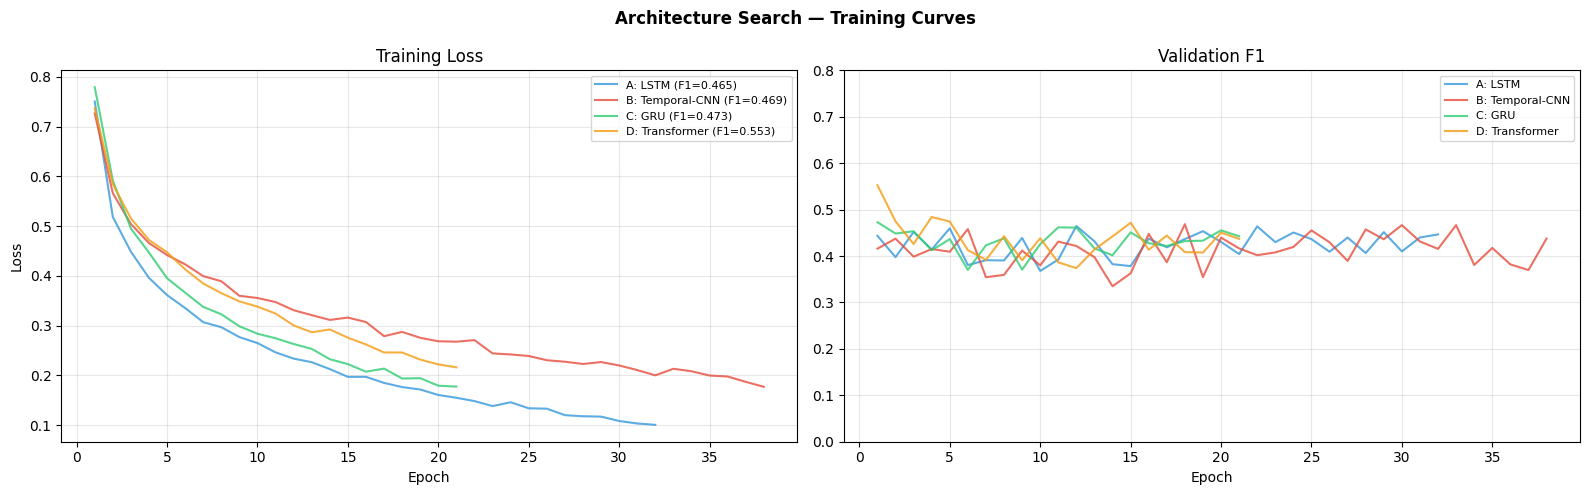

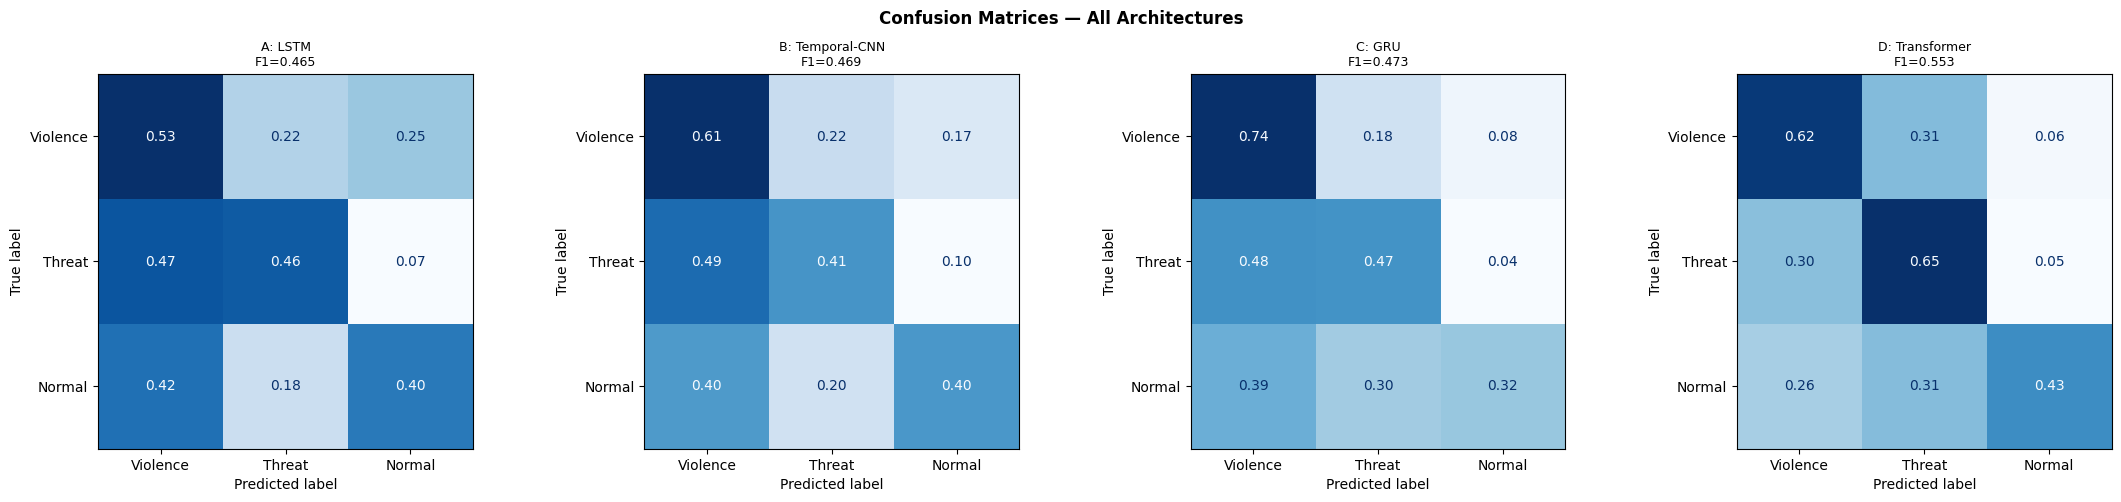


Overfitting diagnostic:
  A: LSTM                loss=0.1006 (✅ learning)  spread=0.0450 (✅)
  B: Temporal-CNN        loss=0.1771 (✅ learning)  spread=0.0679 (✅)
  C: GRU                 loss=0.1776 (✅ learning)  spread=0.0334 (✅)
  D: Transformer         loss=0.2163 (✅ learning)  spread=0.0429 (✅)

📈 D: Transformer improved over previous skeleton best (0.5526 vs 0.5500)
   Gap to CNN+LSTM v3: 0.0854


In [19]:
def get_m(yt, yp, cls, metric='recall'):
    ci = TARGET_CLASSES.index(cls)
    fn = recall_score if metric == 'recall' else precision_score
    r = fn(yt, yp, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

# ── Master comparison table ───────────────────────────────────────────────────
print('='*90)
print('  ARCHITECTURE COMPARISON — Same skeleton data, different models')
print('='*90)
print(f'  {"Model":<22} {"Params":>8} {"F1":>7} {"Acc":>7} {"VioR":>6} {"ThrR":>6} {"NorR":>6} {"Time":>7}')
print('  ' + '-'*75)

# Reference rows
print(f'  {"CNN+LSTM v3 (pixels)":<22} {"2.3M":>8} {"0.638":>7} {"0.668":>7} {"0.57":>6} {"0.26":>6} {"0.92":>6} {"3.5h":>7}')
print(f'  {"Skel-LSTM v2 (prev)":<22} {"386K":>8} {"0.550":>7} {"0.557":>7} {"0.81":>6} {"0.59":>6} {"0.37":>6} {"21m":>7}')
print('  ' + '-'*75)

best_result = None
for r in all_results:
    yt, yp = r['y_true'], r['y_pred']
    acc = accuracy_score(yt, yp)
    f1 = r['best_f1']
    vr = get_m(yt, yp, 'Violence')
    tr = get_m(yt, yp, 'Threat')
    nr = get_m(yt, yp, 'Normal')
    m, s = divmod(int(r['elapsed']), 60)
    pk = f'{r["params"]/1000:.0f}K'
    marker = ''
    if best_result is None or f1 > best_result['best_f1']:
        best_result = r
    print(f'  {r["name"]:<22} {pk:>8} {f1:>7.4f} {acc:>7.4f} {vr:>6.2f} {tr:>6.2f} {nr:>6.2f} {m}m{s:02d}s')

# Mark winner
print('  ' + '-'*75)
winner = best_result['name']
winner_f1 = best_result['best_f1']
print(f'  Winner: {winner} (F1={winner_f1:.4f})')
print('='*90)

# ── Per-class report for winner ───────────────────────────────────────────────
print(f'\nPer-class breakdown — {winner}:')
print(classification_report(best_result['y_true'], best_result['y_pred'],
      target_names=TARGET_CLASSES, zero_division=0))

# ── Training curves ───────────────────────────────────────────────────────────
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for r, c in zip(all_results, colors):
    ep = range(1, len(r['history']['f1']) + 1)
    axes[0].plot(ep, r['history']['loss'], '-', color=c, linewidth=1.5,
                 label=f'{r["name"]} (F1={r["best_f1"]:.3f})', alpha=0.8)
    axes[1].plot(ep, r['history']['f1'], '-', color=c, linewidth=1.5,
                 label=r['name'], alpha=0.8)

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[1].set_title('Validation F1'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 0.8); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

plt.suptitle('Architecture Search — Training Curves', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Confusion matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, r in zip(axes, all_results):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_n, display_labels=TARGET_CLASSES).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f'{r["name"]}\nF1={r["best_f1"]:.3f}', fontsize=9)
plt.suptitle('Confusion Matrices — All Architectures', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Overfitting diagnostic ───────────────────────────────────────────────────
print('\nOverfitting diagnostic:')
for r in all_results:
    fl = r['history']['loss'][-1]
    status = '✅ learning' if fl > 0.1 else ('⚠ mild overfit' if fl > 0.01 else '❌ memorizing')
    f1_spread = max(r['history']['f1'][-5:]) - min(r['history']['f1'][-5:]) if len(r['history']['f1']) >= 5 else 0
    stable = '✅' if f1_spread < 0.05 else ('✅' if f1_spread < 0.1 else '⚠')
    print(f'  {r["name"]:<22} loss={fl:.4f} ({status})  spread={f1_spread:.4f} ({stable})')

# ── Final recommendation ──────────────────────────────────────────────────────
print()
prev_best = 0.550  # skeleton v2
cnn_best = 0.638   # CNN+LSTM v3
if winner_f1 > cnn_best:
    print(f'🏆 {winner} BEATS CNN+LSTM v3! ({winner_f1:.4f} vs {cnn_best:.4f})')
    print(f'   Skeleton approach surpassed pixel-based with the right architecture.')
elif winner_f1 > prev_best:
    print(f'📈 {winner} improved over previous skeleton best ({winner_f1:.4f} vs {prev_best:.4f})')
    delta = cnn_best - winner_f1
    print(f'   Gap to CNN+LSTM v3: {delta:.4f}')
else:
    print(f'📊 Best skeleton: {winner_f1:.4f} (prev was {prev_best:.4f}, CNN+LSTM v3 was {cnn_best:.4f})')
